This tutorial will cover how to generate UVLFs from Zeus21. It is recommended to do the basics tutorial first, to get a handle on how the code works. That said, this can stand on its own, so let's go!

In [51]:
import zeus21
from matplotlib import pyplot as plt
import numpy as np
import copy

# Set up the user parameters
UserParams = zeus21.User_Parameters(precisionboost=1.2)

We first set up the cosmology and astrophysics. 

We do not need to go as far as the 21-cm calculation when doing UVLFs. We do not need the Coeff or PS21 structures (since we won't compute 21-cm in this tutorial), nor do we need the correlation functions. We do need the HMFs, though.

The astrophysical parameters are shared between the UVLF and the 21-cm calculation, so one can jointly do inference. 

In [ ]:
# Set up the Zeus21 cosmology
CosmoParams = zeus21.Cosmo_Parameters(UserParams=UserParams, HMF_CHOICE="ST", zmin_CLASS=0.0)  # CLASS is automatically run by the Cosmo_Parameter class; make sure to provide zmin_CLASS lower than default (5.0) if you want lower z results (e.g. HMFs)
HMFinterp = zeus21.HMF_interpolator(UserParams, CosmoParams)  # HMF at all desired z and M; here HMF from Sheth&Tormen2002 (https://arxiv.org/abs/astro-ph/0105113)

# Set up the astrophysical parameters
AstroParams = zeus21.Astro_Parameters(CosmoParams=CosmoParams, accretion_model="exp")  # Here exponential accretion model, as in https://arxiv.org/abs/2306.09403

Now we have to define the LF parameters. You can run with the default set, but let's spice things up a bit. Let's define two:
- one with a standard halo-galaxy connection;
- one with a very stochastic halo-galaxy connection, but lower UV brightness per galaxy (smaller f* at peak).

We also have to define the redshift and magnitudes over which to plot. You give an arbitrary \<z\> and width dz, and the code will assume the selection function is a Gaussian around it. For magnitudes, you provide centers and widths of bins, assumed to be tophats. It will then generate the UVLF under those specs. Make sure the binning of z and MUV are the same as whatever data you're considering!

In [53]:
z, dz = 5.0, 0.5  # Central z and width (assumed Gaussian)

MUV_centers = np.linspace(-17,-23,13)  # Centers of MUV bins
MUV_widths = -np.diff(MUV_centers)
MUV_widths = np.append(MUV_widths, MUV_widths[-1])

# Set up the LF parameters
LFParams_std = zeus21.LF_Parameters(zcenter=z, zwidth=dz, MUVcenters=MUV_centers, MUVwidths=MUV_widths)
LFParams_bursty = zeus21.LF_Parameters(zcenter=z, zwidth=dz, MUVcenters=MUV_centers, MUVwidths=MUV_widths, sigmaUV=0.9)

So we can now compute and plot the UVLFs with our adopted parameters. If you're new to the world of the UVLFs, note that the x axis is a UV absolute magnitude, and y is the comoving number density of galaxies at that magnitude (divided by the width of the bin).

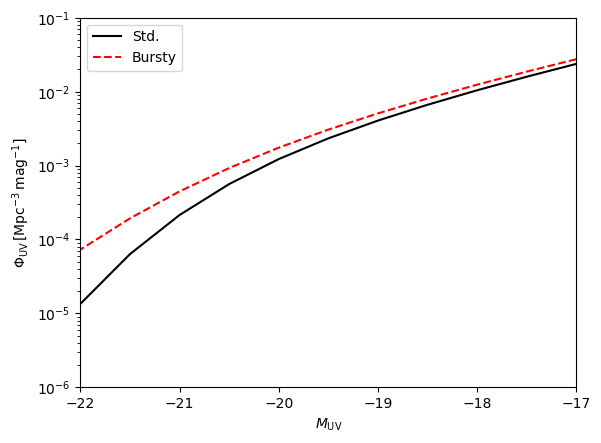

In [ ]:
UVLF_std = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_std).UVLFbias_outputs["tot"]["LF"]  # TODO: Here and in the following, adjust for uniform outputs with T21 coefficients
UVLF_bursty = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_bursty).UVLFbias_outputs["tot"]["LF"]

plt.semilogy(MUV_centers, UVLF_std, 'k-', label="Std.")
plt.semilogy(MUV_centers, UVLF_bursty,'r--', label="Bursty")
plt.xlim(-22,-17)
plt.ylim(1e-6,1e-1)
plt.xlabel(r'$M_{\rm UV}$');
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

Let's play around with parameters.

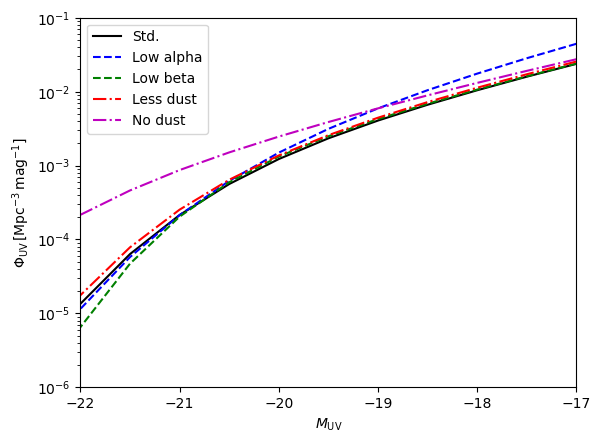

In [ ]:
# First, let's change the astrophysical parameters alpha and beta too to see what they do
AstroParams_lowalpha = copy.deepcopy(AstroParams)
AstroParams_lowalpha.alphastar -= 0.2
UVLF_lowalpha = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams_lowalpha, HMFinterp, LFParams_std).UVLFbias_outputs["tot"]["LF"]

AstroParams_lowbeta = copy.deepcopy(AstroParams)
AstroParams_lowbeta.betastar -= 0.2
UVLF_lowbeta = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams_lowbeta, HMFinterp, LFParams_std).UVLFbias_outputs["tot"]["LF"]

# And the dust assumptions in the LF parameters -- they can be degenerate! (Beware, these are measured independently, see Refs.)
LFParams_lessdust = copy.deepcopy(LFParams_std)
LFParams_lessdust.C0dust -= 0.1
UVLF_lessdust = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_lessdust).UVLFbias_outputs["tot"]["LF"]
LFParams_nodust = copy.deepcopy(LFParams_std)  # Added by AV for one-to-one comparison previous tutorial: note that small discrepancy with respect to previous notebook in both UVLF and bias at the bright end, likely due to the different dust loop, while results are recovered with no dust --> TODO: discuss changes with others and whether we should give a warning of some sort
LFParams_nodust.DUST_FLAG = False
UVLF_nodust = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_nodust).UVLFbias_outputs["tot"]["LF"]

plt.semilogy(MUV_centers, UVLF_std, 'k-', label="Std.")
plt.semilogy(MUV_centers, UVLF_lowalpha,'b--', label="Low alpha")
plt.semilogy(MUV_centers, UVLF_lowbeta,'g--', label="Low beta")
plt.semilogy(MUV_centers, UVLF_lessdust,'r-.', label="Less dust")
plt.semilogy(MUV_centers, UVLF_nodust,'m-.', label="No dust")
plt.xlim(-22,-17)
plt.ylim(1e-6,1e-1)
plt.xlabel(r'$M_{\rm UV}$');
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

Zeus allows to compute the bias as a function of MUV as well. Let's do that and plot it!

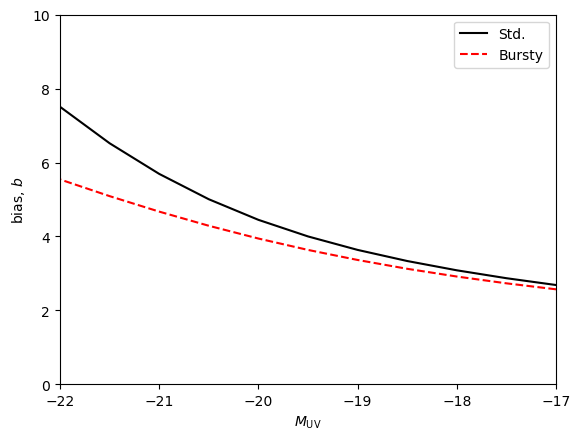

In [ ]:
LFParams_std_bias = copy.deepcopy(LFParams_std)
LFParams_std_bias.RETURNBIAS = True
LFParams_std_bias.RETURNLF = False  # We already computed the UVLF (needed for the bias normalization, see later), so we don't need to compute it again, however both can be computed at the same time if both flags are True
bias_UVLF_std = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_std_bias).UVLFbias_outputs["tot"]["bias"]/UVLF_std  # Note it's divided by UVLF, since the bias returns #<b>*Phi on each MUV bin, so you have to divide by UVLF to get the bias alone

LFParams_bursty_bias = copy.deepcopy(LFParams_bursty)
LFParams_bursty_bias.RETURNBIAS = True
LFParams_bursty_bias.RETURNLF = False
bias_UVLF_bursty = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_bursty_bias).UVLFbias_outputs["tot"]["bias"]/UVLF_bursty

#LFParams_nodust_bias = copy.deepcopy(LFParams_nodust)  # TODO: remove this part, used for debugging purposes, in order to compare with previous notebook given the different dust loop
#LFParams_nodust_bias.RETURNBIAS = True
#LFParams_nodust_bias.RETURNLF = False
#bias_UVLF_nodust = zeus21.LFs.LF_class(UserParams, CosmoParams, AstroParams, HMFinterp, LFParams_nodust_bias).UVLFbias_outputs["tot"]["bias"]/UVLF_nodust

plt.plot(MUV_centers, bias_UVLF_std, 'k-', label="Std.")
#plt.plot(MUV_centers, bias_UVLF_nodust, 'k-.', label="No dust")
plt.plot(MUV_centers, bias_UVLF_bursty, 'r--', label="Bursty")
plt.xlim(-22, -17)
plt.ylim(0, 10)
plt.xlabel(r'$M_{\rm UV}$')
plt.ylabel(r'bias, $b$')
plt.legend()

Note a possible issue: for no/low stochasticity (sigmaUV~0) the UVLF becomes noisy because there are not enough halos in each MUV bin. Can be fixed change precisionboost in constants.py - as we'll do in the next part for Pop IIIs.

Now let's add Pop III stars. Note that Pop IIIs will normally be very faint, so you'll need to go to fainter MUVs to see their effect. We also need higher precisionboost for higher accuracy at these faint MUVs, so we need to recompute the cosmology.

In [ ]:
UserParams_III = zeus21.User_Parameters(precisionboost=2.2)  # For accurate results down to MUV~-6

CosmoParams_III = zeus21.Cosmo_Parameters(UserParams=UserParams_III, HMF_CHOICE="ST")
HMFinterp_III = zeus21.HMF_interpolator(UserParams_III, CosmoParams_III)

AstroParams_III = zeus21.Astro_Parameters(CosmoParams=CosmoParams_III, accretion_model="exp", USE_POPIII=True)  # USE_POPIII = True in the astrophysical parameters to add Pop IIIs to the SFR calculation

z_III, dz_III = 15.0, 0.5  # We pick a higher redshift to better see the effects at the low-mass end

MUV_centers_III = np.linspace(-5,-23,100)  # We extend to fainter MUVs and increase the number of MUV points
MUV_widths_III = -np.diff(MUV_centers_III)
MUV_widths_III = np.append(MUV_widths_III, MUV_widths_III[-1])

LFParams_III = zeus21.LF_Parameters(zcenter=z_III, zwidth=dz_III, MUVcenters=MUV_centers_III, MUVwidths=MUV_widths_III, SKIP_POPIII=False)  # SKIP_POPIII = False is needed to add the Pop III UVLF calculation - note that this only works if USE_POPIII = True in the astrophysical parameters!

/home/alessandra/miniconda3/envs/zeus21_v2test/lib/python3.11/site-packages/zeus21/LFs.py:172: RuntimeWarning: divide by zero encountered in log10
  return constants.zeropoint_ABmag_ergsHz - 2.5 * np.log10(L)  # AB magnitude


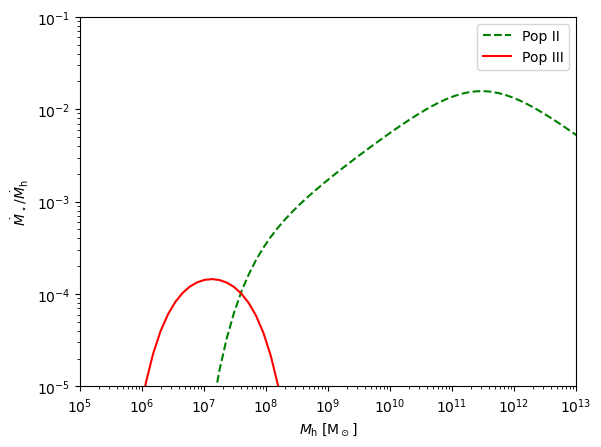

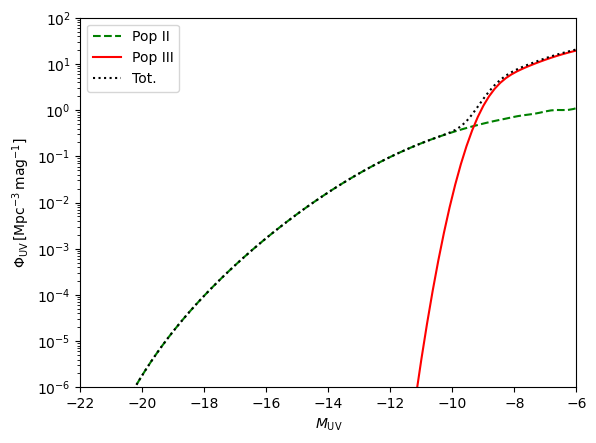

In [ ]:
# Now we can compute both the Pop III and Pop II components to the UVLF and look at the two contributions separately
UVLFbias_outputs = zeus21.LFs.LF_class(UserParams_III, CosmoParams_III, AstroParams_III, HMFinterp_III, LFParams_III).UVLFbias_outputs
UVLF_tot = UVLFbias_outputs["tot"]["LF"]
UVLF_pop2 = UVLFbias_outputs["popII"]["LF"]
UVLF_pop3 = UVLFbias_outputs["popIII"]["LF"]

# We first plot the SFR per unit halo mass for both components to show what's going into the UVLFs
SFRD = zeus21.sfrd.SFRD_class(UserParams_III, CosmoParams_III, AstroParams_III, HMFinterp_III)
SFE_pop2 = SFRD.SFE(CosmoParams_III, AstroParams_III, HMFinterp_III.Mhtab, z_III, pop=2)
SFE_pop3 = SFRD.SFE(CosmoParams_III, AstroParams_III, HMFinterp_III.Mhtab, z_III, pop=3, vCB=False, J21LW_interp=SFRD.J21LW_interp_conv_avg)  # Note that here we need to provide vCB and LW explicitly for this to work, as by default these are put to None, so it doesn't work --> TODO: discuss default init of vcb and J21LW in SFRD for simmetry; also at what z is the conv. avg. computed?
plt.figure()
plt.loglog(HMFinterp_III.Mhtab, SFE_pop2, 'g--', label="Pop II")
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3, 'r-', label="Pop III")  # TODO: check slightly higher Pop III SFE than in default by Cruz+25 fig. 2? (this should account correctly for the factor 2 in normalization after replacing the old fstar_III with epsstar_III = fstar_III/2 for symmetry with Pop IIs, perhaps it's something in the LW that is different?)
plt.xlim(1e5, 1e13)
plt.ylim(1e-5, 1e-1)
plt.xlabel(r"$M_{\rm h} \; [\mathrm{M_\odot}]$")
plt.ylabel(r"$\dot{M}_\star / \dot{M}_\mathrm{h}$")
plt.legend()

# And then the resulting UVLFs
plt.figure()
plt.semilogy(MUV_centers_III, UVLF_pop2, 'g--', label="Pop II")
plt.semilogy(MUV_centers_III, UVLF_pop3, 'r-', label="Pop III")
plt.semilogy(MUV_centers_III, UVLF_tot, 'k:', label="Tot.")
plt.xlim(-22, -6)
plt.ylim(1e-6, 1e2)
plt.xlabel(r'$M_{\rm UV}$')
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

Then we play around with the physics affecting Pop III star formation at the low-mass end: LW feedback and streaming velocities (see e.g. https://arxiv.org/abs/2407.18294).

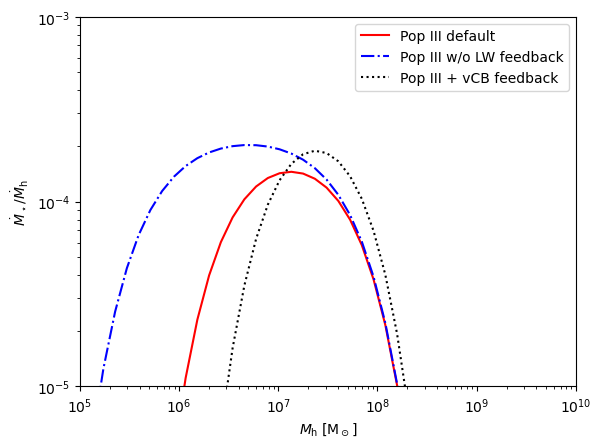

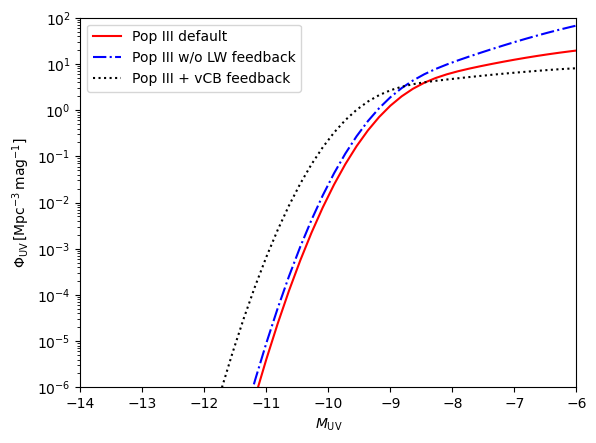

In [ ]:
# Case with no LW feedback
SFE_pop3_noLW = SFRD.SFE(CosmoParams_III, AstroParams_III, HMFinterp_III.Mhtab, z_III, pop=3, J21LW_interp=False, vCB=False)
UVLF_pop3_noLW = zeus21.LFs.LF_class(UserParams_III, CosmoParams_III, AstroParams_III, HMFinterp_III, LFParams_III, J21LW_interp=False).UVLFbias_outputs["popIII"]["LF"]

# Case including feedback from streaming velocities - here we need to redefine the cosmology to include streaming velocities from the start - TODO: discuss possible source of confusion and mistakes, because USE_RELATIVE_VELOCITIES=False by default, but most of the Pop III methods are designed to include streaming velocities by default instead, which may be confusing because the user may expect them to be active, while in reality vcb_avg=0 and the feedback is not taken into account by default; in general, there's a bit of confusion between the defaults, also with the SFRDs (see e.g. previous code block)
CosmoParams_III_vcb = zeus21.Cosmo_Parameters(UserParams=UserParams_III, HMF_CHOICE="ST", USE_RELATIVE_VELOCITIES=True)
HMFinterp_III_vcb = zeus21.HMF_interpolator(UserParams_III, CosmoParams_III_vcb)
AstroParams_III_vcb = zeus21.Astro_Parameters(CosmoParams=CosmoParams_III_vcb, accretion_model="exp", USE_POPIII=True)
SFRD_vcb = zeus21.sfrd.SFRD_class(UserParams_III, CosmoParams_III_vcb, AstroParams_III_vcb, HMFinterp_III_vcb)
SFE_pop3_vcb = SFRD_vcb.SFE(CosmoParams_III_vcb, AstroParams_III_vcb, HMFinterp_III_vcb.Mhtab, z_III, pop=3, J21LW_interp=SFRD.J21LW_interp_conv_avg, vCB=CosmoParams_III_vcb.vcb_avg)
UVLF_pop3_vcb = zeus21.LFs.LF_class(UserParams_III, CosmoParams_III_vcb, AstroParams_III_vcb, HMFinterp_III_vcb, LFParams_III).UVLFbias_outputs["popIII"]["LF"]

plt.figure()
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3, 'r-', label="Pop III default")
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3_noLW, 'b-.', label="Pop III w/o LW feedback")
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3_vcb, 'k:', label="Pop III + vCB feedback")
plt.xlim(1e5, 1e10)
plt.ylim(1e-5, 1e-3)
plt.xlabel(r"$M_{\rm h} \; [\mathrm{M_\odot}]$")
plt.ylabel(r"$\dot{M}_\star / \dot{M}_\mathrm{h}$")
plt.legend()

plt.figure()
plt.semilogy(MUV_centers_III, UVLF_pop3, 'r-', label="Pop III default")
plt.semilogy(MUV_centers_III, UVLF_pop3_noLW, 'b-.', label="Pop III w/o LW feedback")
plt.semilogy(MUV_centers_III, UVLF_pop3_vcb, 'k:', label="Pop III + vCB feedback")
plt.xlim(-14, -6)
plt.ylim(1e-6, 1e2)
plt.xlabel(r'$M_{\rm UV}$')
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

Finally, let's see what happens if we extend Pop III formation beyond minihalos and into the atomic-cooling halo regime, as in https://arxiv.org/abs/2505.20263.

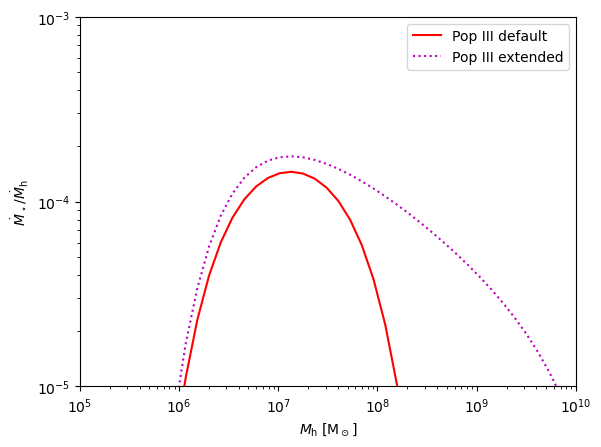

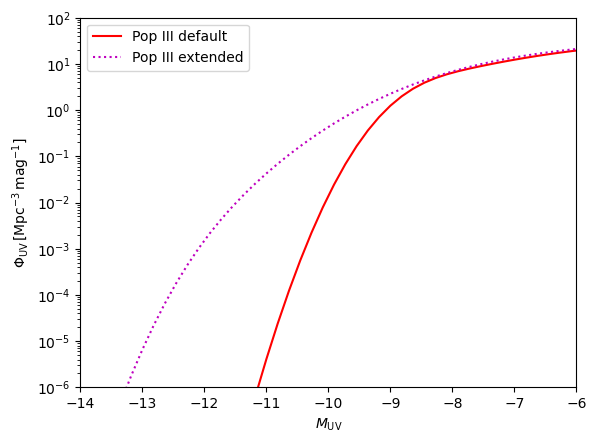

In [ ]:
AstroParams_III_ACH = copy.deepcopy(AstroParams_III)
AstroParams_III_ACH.Mup_III = 1e10  # We extend the high-mass cut-off (set to the atomic-cooling mass at current z by default) up to a fixed value of 1e10 Msun
AstroParams_III_ACH.betastar_III = -0.5  # Let's also change the slope at the high-mass end, for fun
SFRD_ACH = zeus21.sfrd.SFRD_class(UserParams_III, CosmoParams_III, AstroParams_III_ACH, HMFinterp_III)
SFE_pop3_ACH = SFRD_ACH.SFE(CosmoParams_III, AstroParams_III_ACH, HMFinterp_III.Mhtab, z_III, pop=3, vCB=False, J21LW_interp=SFRD.J21LW_interp_conv_avg)
UVLF_pop3_ACH = zeus21.LFs.LF_class(UserParams_III, CosmoParams_III, AstroParams_III_ACH, HMFinterp_III, LFParams_III).UVLFbias_outputs["popIII"]["LF"]

plt.figure()
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3, 'r-', label="Pop III default")
plt.loglog(HMFinterp_III.Mhtab, SFE_pop3_ACH, 'm:', label="Pop III extended")
plt.xlim(1e5, 1e10)
plt.ylim(1e-5, 1e-3)
plt.xlabel(r"$M_{\rm h} \; [\mathrm{M_\odot}]$")
plt.ylabel(r"$\dot{M}_\star / \dot{M}_\mathrm{h}$")
plt.legend()

plt.figure()
plt.semilogy(MUV_centers_III, UVLF_pop3, 'r-', label="Pop III default")
plt.semilogy(MUV_centers_III, UVLF_pop3_ACH, 'm:', label="Pop III extended")
plt.xlim(-14, -6)
plt.ylim(1e-6, 1e2)
plt.xlabel(r'$M_{\rm UV}$')
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

TODO: Play around also with a detached ACH component? Although this was not published yet, so probably an overkill for now

TODO: Other block playing with Pop III UV boost (potentially including the IMF-dependence as suggested by Sahil) and burstiness? Although I'd say also probably an overkill and maybe better to add after we use this in some published results